### Описание набора данных

Этот набор данных предназначен для прогнозирования стоимости поездок на такси на основе различных факторов, таких как расстояние, время суток, дорожная обстановка и многое другое. Он предоставляет реалистичные синтетические данные для задач регрессионного анализа, предлагая уникальную возможность изучить тенденции ценообразования в индустрии такси.

In [2]:
import pandas as pd

from private import utils
from public import analyzer

data_frame : pd.DataFrame = utils.prepare_taxi_data()
analyzer.report(
    data_frame,
    [
        analyzer.dataset_stats_info,
        analyzer.duplicates_info,
        analyzer.missing_value_info,
        analyzer.not_numeric_columns_info,
        analyzer.anomalies_info
    ] 
)


total
	1000

head
	   Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
	0             19.35     Morning     Weekday              3.0   
	1             47.59   Afternoon     Weekday              1.0   
	2             36.87     Evening     Weekend              1.0   
	3             30.33     Evening     Weekday              4.0   
	4               NaN     Evening     Weekday              3.0   

	  Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
	0                Low   Clear       3.56         0.80             0.32   
	1               High   Clear        NaN         0.62             0.43   
	2               High   Clear       2.70         1.21             0.15   
	3                Low     NaN       3.48         0.51             0.15   
	4               High   Clear       2.93         0.63             0.32   

	   Trip_Duration_Minutes  Trip_Price  
	0                  53.82     36.2624  
	1                  40.57         NaN  
	2                  37.27

preprocessing took 0.055 seconds
training took 0.003 seconds
predict took 0.000 seconds
evaluate took 0.000 seconds
Коэффициенты линейной регрессии:
	[ 1.70004824e+00 -2.24209464e-01 -9.87487129e-01 -1.44345869e-01
  8.80982095e-02  4.10916516e-02  3.40118001e-01  2.19073146e+01
  4.30271496e+01  2.50979895e-01]
Intercept:
	-43.744781835040676
Среднеквадратичная ошибка:
	376.1551002721801
Коэффициент детерминации R^2:
	0.5448825604410118
report took 0.000 seconds


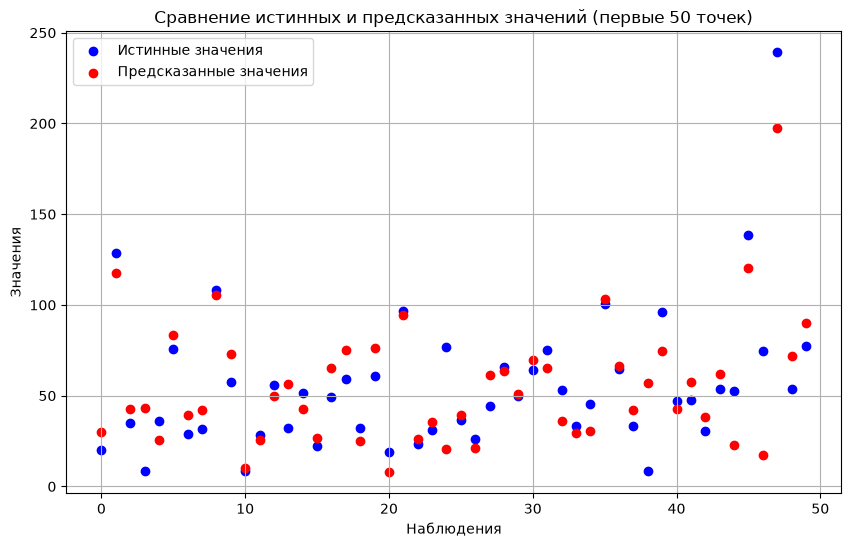

In [4]:
from public.model_for_linear_regresssion import LinearRegressionModel

model: LinearRegressionModel = (
        LinearRegressionModel(df=data_frame, target_column="Trip_Price", test_size=0.25)  # set datadrame
        .preprocessing(  # transmrm dataframe based on analizer info
            {
                "fill_missing_data": {"strategy": "most_frequent"},
                "ordinal_encoding": {
                    "columns": [
                        "Time_of_Day",
                        "Day_of_Week",
                        "Traffic_Conditions",
                        "Weather",
                    ]
                },
                # "standard_scaller": {},
            }
        )
        .training()  # trainig
        .predict()  # predicttion based on test data
        .evaluate()  # evaluate model presicion
)
model.report()
model.draw()